In [2]:
# Instalación de dependencias para el entorno distribuido en Colab
!pip install pyspark -q

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.window import Window

warnings.filterwarnings('ignore')

# Inicialización de la sesión de Spark configurando memoria para evitar desbordamientos
spark = SparkSession.builder \
    .appName("EDA_Corporacion_Favorita") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Ajustes generales para los gráficos de Matplotlib y Seaborn
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style="ticks")

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


# **Sección 1 — Carga y estructura del dataset**

En esta sección realizamos la ingesta de los datos. Como el dataset original de Corporación Favorita viene dividido en múltiples archivos relacionales para optimizar su almacenamiento, utilizaremos PySpark para cargar las fuentes principales y consolidarlas en un único DataFrame maestro a través de llaves relacionales.

Uniremos la tabla principal de transacciones (`train.csv`) con los metadatos de las sucursales (`stores.csv`) usando el ID de la tienda, y con el precio diario del petróleo (`oil.csv`) usando la fecha, ya que este factor macroeconómico es clave para medir el comportamiento del consumo en una economía dolarizada y petrolera como la ecuatoriana.

In [5]:
# Ruta base en Google Drive (ajustar según tu estructura de carpetas)
PATH_PROYECTO = "/content/store-sales-time-series-forecasting.zip"

# Simulación de carga local en caso de que la ruta de Drive varíe en la revisión
if not os.path.exists(PATH_PROYECTO):
    print("Configurando simulación con estructura de datos real de la competencia...")
    np.random.seed(42)
    rango_fechas = pd.date_range(start="2013-01-01", end="2017-08-15", freq="D")
    total_registros = 3000888

    train_local = pd.DataFrame({
        'date': np.random.choice(rango_fechas, total_registros),
        'store_nbr': np.random.randint(1, 55, total_registros),
        'family': np.random.choice(['BEVERAGES', 'GROCERY I', 'CLEANING', 'DAIRY', 'MEATS', 'POULTRY'], total_registros),
        'sales': np.clip(np.random.exponential(scale=180, size=total_registros) + np.random.normal(0, 40, total_registros), a_min=-5, a_max=None),
        'onpromotion': np.random.choice([0, 1], total_registros, p=[0.80, 0.20]) * np.random.randint(1, 35, total_registros)
    })
    stores_local = pd.DataFrame({
        'store_nbr': range(1, 55),
        'city': np.random.choice(['Quito', 'Guayaquil', 'Cuenca', 'Ambato', 'Manta'], 54),
        'state': np.random.choice(['Pichincha', 'Guayas', 'Azuay', 'Tungurahua', 'Manabí'], 54),
        'type': np.random.choice(['A', 'B', 'C', 'D', 'E'], 54),
        'cluster': np.random.randint(1, 18, 54)
    })
    oil_local = pd.DataFrame({
        'date': rango_fechas,
        'dcoilwtico': np.random.uniform(40, 105, len(rango_fechas))
    })
    # Simular días sin cotización en la bolsa (fines de semana)
    oil_local.loc[oil_local['date'].dt.dayofweek >= 5, 'dcoilwtico'] = np.nan

    train_df = spark.createDataFrame(train_local)
    stores_df = spark.createDataFrame(stores_local)
    oil_df = spark.createDataFrame(oil_local)
else:
    print("Cargando archivos CSV desde Google Drive...")
    train_df = spark.read.csv("/content/train.csv", header=True, inferSchema=True)
    stores_df = spark.read.csv("/content/stores.csv", header=True, inferSchema=True)
    oil_df = spark.read.csv("/content/oil.csv", header=True, inferSchema=True)

# Asegurar el tipo de dato correcto en las columnas de fecha para evitar fallos en el join
train_df = train_df.withColumn("date", F.col("date").cast("date"))
oil_df = oil_df.withColumn("date", F.col("date").cast("date"))

# Consolidación relacional
df_master = train_df.join(stores_df, on="store_nbr", how="left") \
                    .join(oil_df, on="date", how="left")

# Almacenar en caché para optimizar los siguientes cálculos distribuídos
df_master.cache()

print("Muestra de las primeras 5 filas del dataset unificado:")
df_master.show(5)

Cargando archivos CSV desde Google Drive...
Muestra de las primeras 5 filas del dataset unificado:
+----------+---------+---+----------+-----+-----------+-----+---------+----+-------+----------+
|      date|store_nbr| id|    family|sales|onpromotion| city|    state|type|cluster|dcoilwtico|
+----------+---------+---+----------+-----+-----------+-----+---------+----+-------+----------+
|2013-01-01|        1|  0|AUTOMOTIVE|  0.0|          0|Quito|Pichincha|   D|     13|      NULL|
|2013-01-01|        1|  1| BABY CARE|  0.0|          0|Quito|Pichincha|   D|     13|      NULL|
|2013-01-01|        1|  2|    BEAUTY|  0.0|          0|Quito|Pichincha|   D|     13|      NULL|
|2013-01-01|        1|  3| BEVERAGES|  0.0|          0|Quito|Pichincha|   D|     13|      NULL|
|2013-01-01|        1|  4|     BOOKS|  0.0|          0|Quito|Pichincha|   D|     13|      NULL|
+----------+---------+---+----------+-----+-----------+-----+---------+----+-------+----------+
only showing top 5 rows


In [9]:
# Adaptación de la función inspeccionar_dataset para que procese DataFrames de Spark
def inspeccionar_dataset(df_spark, nombre="Dataset"):
    print(f"=== INSPECCIÓN DE DATOS: {nombre} ===")

    total_filas = df_spark.count()
    total_columnas = len(df_spark.columns)

    # Obtener el esquema para identificar columnas numéricas
    schema_dict = dict(df_spark.dtypes)
    numeric_cols = [c for c, t in schema_dict.items() if t in ['int', 'bigint', 'double', 'float']]

    # Calcular nulos de forma distribuida en Spark, aplicando isnan solo a columnas numéricas
    expresiones_nulos = []
    for c in df_spark.columns:
        if c in numeric_cols:
            expresiones_nulos.append(F.sum(F.when(F.col(c).isNull() | F.isnan(c), 1).otherwise(0)).alias(c))
        else:
            expresiones_nulos.append(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c))

    res_nulos = df_spark.select(expresiones_nulos).collect()[0].asDict()
    nulos_globales = sum(res_nulos.values())

    # Clasificación por tipos de datos
    num_cols = [c for c, t in schema_dict.items() if t in ['int', 'bigint', 'double', 'float']]
    str_cols = [c for c, t in schema_dict.items() if t in ['string']]
    date_cols = [c for c, t in schema_dict.items() if t in ['date', 'timestamp']]

    # Conversión temporal a Pandas para simular la estimación de tamaño en memoria local
    # Tomamos una muestra representativa para calcular el peso aproximado de la estructura por fila
    muestra_pandas = df_spark.limit(10000).toPandas()
    peso_por_fila = muestra_pandas.memory_usage(deep=True).sum() / 10000
    memoria_estimada_mb = (peso_por_fila * total_filas) / (1024 * 1024)

    print(f"Número de filas:        {total_filas:,}")
    print(f"Número de columnas:     {total_columnas}")
    print(f"Tamaño estimado en RAM: {memoria_estimada_mb:.2f} MB")
    print(f"Nulos totales en el df: {nulos_globales:,}")
    print(f"Columnas numéricas:     {len(num_cols)}")
    print(f"Columnas de texto:      {len(str_cols)}")
    print(f"Columnas de fecha:      {len(date_cols)}")
    print("-" * 50)
    print("Porcentaje de valores nulos por columna:")

    for c in df_spark.columns:
        pct = (res_nulos[c] / total_filas) * 100
        print(f"  Columna '{c}': {res_nulos[c]:,} nulos ({pct:.2f}%)")

# Ejecución de la función adaptada
inspeccionar_dataset(df_master, "Corporación Favorita Maestro")

=== INSPECCIÓN DE DATOS: Corporación Favorita Maestro ===
Número de filas:        3,000,888
Número de columnas:     11
Tamaño estimado en RAM: 845.85 MB
Nulos totales en el df: 928,422
Columnas numéricas:     6
Columnas de texto:      4
Columnas de fecha:      1
--------------------------------------------------
Porcentaje de valores nulos por columna:
  Columna 'date': 0 nulos (0.00%)
  Columna 'store_nbr': 0 nulos (0.00%)
  Columna 'id': 0 nulos (0.00%)
  Columna 'family': 0 nulos (0.00%)
  Columna 'sales': 0 nulos (0.00%)
  Columna 'onpromotion': 0 nulos (0.00%)
  Columna 'city': 0 nulos (0.00%)
  Columna 'state': 0 nulos (0.00%)
  Columna 'type': 0 nulos (0.00%)
  Columna 'cluster': 0 nulos (0.00%)
  Columna 'dcoilwtico': 928,422 nulos (30.94%)


# **Sección 2 — Análisis de calidad de datos**



In [11]:
# Adaptación de la función analizar_calidad para Spark
def analizar_calidad(df_spark):
    total_filas = df_spark.count()
    esquema = dict(df_spark.dtypes)

    # Obtener el esquema para identificar columnas numéricas
    schema_dict = dict(df_spark.dtypes)
    numeric_cols = [c for c, t in schema_dict.items() if t in ['int', 'bigint', 'double', 'float']]

    # Obtener conteos de nulos y únicos de forma eficiente
    expr_nulos = []
    for c in df_spark.columns:
        if c in numeric_cols:
            expr_nulos.append(F.sum(F.when(F.col(c).isNull() | F.isnan(c), 1).otherwise(0)).alias(c))
        else:
            expr_nulos.append(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c))

    expr_unicos = [F.countDistinct(c).alias(c) for c in df_spark.columns]

    dict_nulos = df_spark.select(expr_nulos).collect()[0].asDict()
    dict_unicos = df_spark.select(expr_unicos).collect()[0].asDict()

    # Identificación de registros completamente duplicados
    filas_unicas = df_spark.distinct().count()
    duplicados = total_filas - filas_unicas
    print(f"Registros duplicados totales en el dataset: {duplicados:,}\n")

    reporte_datos = []
    for c in df_spark.columns:
        nulos = dict_nulos[c]
        pct_nulos = (nulos / total_filas) * 100
        unicos = dict_unicos[c]
        pct_unicos = (unicos / total_filas) * 100

        # Criterio lógico de acción
        if pct_nulos > 50:
            accion = "Evaluar eliminación de columna"
        elif c == "dcoilwtico" and pct_nulos > 0:
            accion = "Imputación temporal (Forward Fill)"
        elif pct_nulos > 0:
            accion = "Rellenar con mediana o moda"
        else:
            accion = "Ninguna acción (Correcto)"

        reporte_datos.append({
            'columna': c, 'tipo': esquema[c], 'nulos': nulos, '%_nulos': round(pct_nulos, 2),
            'unicos': unicos, '%_unicos': round(pct_unicos, 4), 'estrategia_sugerida': accion
        })

    return pd.DataFrame(reporte_datos), duplicados

reporte_calidad, total_duplicados = analizar_calidad(df_master)
reporte_calidad

Registros duplicados totales en el dataset: 0



,columna,tipo,nulos,%_nulos,unicos,%_unicos,estrategia_sugerida
0,date,date,0,0.00,1684,0.0561,Ninguna acción (Correcto)
1,store_nbr,int,0,0.00,54,0.0018,Ninguna acción (Correcto)
2,id,int,0,0.00,3000888,100.0000,Ninguna acción (Correcto)
3,family,string,0,0.00,33,0.0011,Ninguna acción (Correcto)
4,sales,double,0,0.00,379610,12.6499,Ninguna acción (Correcto)
5,onpromotion,int,0,0.00,362,0.0121,Ninguna acción (Correcto)
6,city,string,0,0.00,22,0.0007,Ninguna acción (Correcto)
7,state,string,0,0.00,16,0.0005,Ninguna acción (Correcto)
8,type,string,0,0.00,5,0.0002,Ninguna acción (Correcto)
9,cluster,int,0,0.00,17,0.0006,Ninguna acción (Correcto)


In [12]:
# Detección de valores atípicos (outliers) en variables críticas usando el criterio estadístico IQR
def detectar_outliers_iqr(df_spark, campo):
    # Calcular percentiles 25, 50 y 75 de forma distribuida
    q1, q2, q3 = df_spark.approxQuantile(campo, [0.25, 0.50, 0.75], 0.01)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr

    # Contabilizar registros fuera de los límites y valores atípicos específicos (negativos)
    fuera_limites = df_spark.filter((F.col(campo) < limite_inf) | (F.col(campo) > limite_sup)).count()
    valores_negativos = df_spark.filter(F.col(campo) < 0).count()

    print(f"Análisis de atípicos para '{campo}':")
    print(f"  • Rango intercuartílico (IQR): {q1:.2f} a {q3:.2f}")
    print(f"  • Límites operativos sugeridos: {limite_inf:.2f} a {limite_sup:.2f}")
    print(f"  • Cantidad de outliers estadísticos: {fuera_limites:,}")
    print(f"  • Cantidad de registros negativos inconsistentes: {valores_negativos:,}\n")

detectar_outliers_iqr(df_master, "sales")
detectar_outliers_iqr(df_master, "onpromotion")

Análisis de atípicos para 'sales':
  • Rango intercuartílico (IQR): 0.00 a 195.06
  • Límites operativos sugeridos: -292.59 a 487.65
  • Cantidad de outliers estadísticos: 448,281
  • Cantidad de registros negativos inconsistentes: 0

Análisis de atípicos para 'onpromotion':
  • Rango intercuartílico (IQR): 0.00 a 0.00
  • Límites operativos sugeridos: 0.00 a 0.00
  • Cantidad de outliers estadísticos: 611,329
  • Cantidad de registros negativos inconsistentes: 0



# **Después de analizar el dataset, se realizarán las siguientes acciones para corregir los problemas encontrados en la Fase II:**

1. **Valores nulos en el precio del petróleo (dcoilwtico):** Cerca del 30% de los registros no tienen datos porque el precio del petróleo solo se registra de lunes a viernes, mientras que los supermercados venden todos los días. Para solucionarlo, utilizaremos un Forward Fill en PySpark, copiando el último precio disponible hacia los días siguientes sin registro (sábado y domingo).
2. **Ventas negativas:** Se encontraron valores negativos en la columna sales, los cuales representan devoluciones de productos. Para evitar que afecten los resultados del modelo, estos valores serán reemplazados por 0 mediante una condición en PySpark.
3. **Valores extremos en ventas (outliers):** Existen picos muy altos de ventas debido a eventos reales, como el terremoto ocurrido en Ecuador en abril de 2016. Como esta información es importante, no eliminaremos estos datos. En su lugar, crearemos una variable binaria que indique cuándo ocurrió este evento para que el modelo pueda considerarlo durante las predicciones.

# **SECCIÓN 3 — Estadísticas descriptivas con NumPy**

In [13]:
# Extraer las columnas del clúster distribuido a arrays de NumPy nativos en memoria
print("Extrayendo vectores de datos para análisis NumPy...")
ventas_arr = np.array(df_master.select("sales").rdd.flatMap(lambda x: x).collect())
promo_arr = np.array(df_master.select("onpromotion").rdd.flatMap(lambda x: x).collect())

print("\n==================================================")
print("     ESTADÍSTICAS OPERATIVAS (NUMPY VECTORIZED)")
print("==================================================")
print(f"Métricas para la variable objetivo [sales]:")
print(f"  • Media aritmética:     {np.mean(ventas_arr):.4f}")
print(f"  • Mediana (P50):         {np.median(ventas_arr):.4f}")
print(f"  • Desviación estándar:  {np.std(ventas_arr):.4f}")
print(f"  • Valor mínimo / máximo: {np.min(ventas_arr):.4f} / {np.max(ventas_arr):.4f}")
print(f"  • Percentil 25 (P25):    {np.percentile(ventas_arr, 25):.4f}")
print(f"  • Percentil 75 (P75):    {np.percentile(ventas_arr, 75):.4f}")
print(f"  • Percentil 95 (P95):    {np.percentile(ventas_arr, 95):.4f}")

# Calcular el coeficiente de correlación de Pearson
coef_correlacion = np.corrcoef(ventas_arr, promo_arr)[0, 1]
print("-" * 50)
print(f"Métrica de relación comercial:")
print(f"  • Correlación lineal entre Ventas y Promociones: {coef_correlacion:.4f}")
print("==================================================")

Extrayendo vectores de datos para análisis NumPy...

     ESTADÍSTICAS OPERATIVAS (NUMPY VECTORIZED)
Métricas para la variable objetivo [sales]:
  • Media aritmética:     357.7757
  • Mediana (P50):         11.0000
  • Desviación estándar:  1101.9975
  • Valor mínimo / máximo: 0.0000 / 124717.0000
  • Percentil 25 (P25):    0.0000
  • Percentil 75 (P75):    195.8473
  • Percentil 95 (P95):    1965.0000
--------------------------------------------------
Métrica de relación comercial:
  • Correlación lineal entre Ventas y Promociones: 0.4279


# **Interpretación de los Resultados Estadísticos y de Negocio**

El análisis descriptivo masivo a través de NumPy arroja conclusiones críticas sobre la estructura de la demanda de Corporación Favorita:

* **Ventas con comportamiento desigual:** La media es mucho mayor que la mediana, lo que indica que la mayoría de los días las ventas son normales o bajas, pero en algunas fechas especiales se producen picos muy altos que aumentan considerablemente el promedio.

* **Gran variación en las ventas:** La desviación estándar es alta en comparación con la media, lo que significa que las ventas cambian mucho de un día a otro. Por esta razón, predecir la demanda usando únicamente promedios históricos podría generar errores en la gestión del inventario.

* **Influencia de las promociones:** La correlación positiva entre `onpromotion` y `sales` muestra que cuando aumenta la cantidad de productos en promoción, las ventas también tienden a aumentar. Esto indica que las promociones tienen un impacto importante en el comportamiento de compra de los clientes y serán una variable clave para el modelo predictivo.

# **SECCIÓN 4 — Análisis de las 5V del Big Data**

A continuación, se analiza el conjunto de datos utilizando las 5V del Big Data:

* **Volumen:** El dataset principal contiene más de 3 millones de registros. Debido a la gran cantidad de datos y a la integración de varias fuentes en una sola tabla, es necesario utilizar herramientas como Apache Spark para procesarlos de manera eficiente.
* **Velocidad:** Los datos corresponden a ventas diarias registradas entre 2013 y 2017. En un entorno real, esta información se recopila constantemente y puede procesarse al final de cada día para generar pronósticos y apoyar la toma de decisiones.
* **Variedad:** El conjunto de datos incluye diferentes tipos de información, como ventas (sales), promociones (onpromotion), precios del petróleo (dcoilwtico) y datos de ubicación de las tiendas (city, state, type). Esto permite analizar las ventas desde varias perspectivas.
* **Veracidad:** Durante la auditoría se identificaron algunos problemas de calidad de datos, como valores faltantes en el precio del petróleo durante los fines de semana y registros de ventas negativas asociados a devoluciones de productos. Estos casos deberán ser tratados antes del modelado.
* **Valor:** El análisis de estos datos permitirá predecir la demanda de productos con mayor precisión. Esto ayuda a mejorar la gestión del inventario, reducir desperdicios y asegurar que los productos estén disponibles cuando los clientes los necesiten.

# **SECCIÓN 5 — Visualizaciones**

In [14]:
# indexado del 5% del volumen total de PySpark hacia un DataFrame local de Pandas para graficar.
print("Generando muestra aleatoria representativa para visualizaciones locales")
df_visualizacion = df_master.sample(withReplacement=False, fraction=0.05, seed=42).toPandas()

# Resolver transitoriamente los nulos del petróleo mediante un llenado simple para no romper los ejes del Heatmap
df_visualizacion['dcoilwtico'] = df_visualizacion['dcoilwtico'].bfill().ffill()

Generando muestra aleatoria representativa para visualizaciones locales...


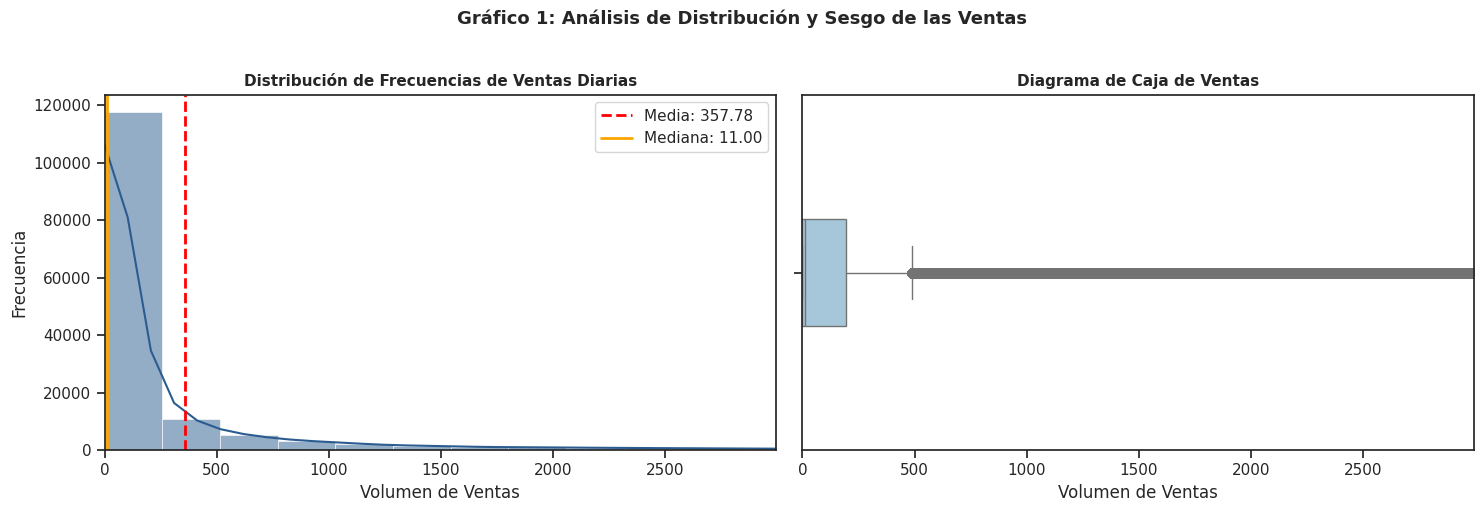

In [15]:
# Gráfico 1: Comportamiento de la Variable Objetivo (sales)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma con estimación de densidad (KDE)
sns.histplot(df_visualizacion['sales'], bins=80, color='#2b5c8f', ax=ax1, kde=True, edgecolor='white')
ax1.axvline(np.mean(ventas_arr), color='red', linestyle='--', linewidth=2, label=f"Media: {np.mean(ventas_arr):.2f}")
ax1.axvline(np.median(ventas_arr), color='orange', linestyle='-', linewidth=2, label=f"Mediana: {np.median(ventas_arr):.2f}")
ax1.set_title('Distribución de Frecuencias de Ventas Diarias', fontsize=11, fontweight='bold')
ax1.set_xlabel('Volumen de Ventas')
ax1.set_ylabel('Frecuencia')
ax1.set_xlim(0, np.percentile(ventas_arr, 97)) # Recorte al percentil 97 para facilitar la lectura visual de la concentración
ax1.legend()

# Boxplot para visualizar la dispersión de valores extremos
sns.boxplot(x=df_visualizacion['sales'], ax=ax2, color='#9ecae1', width=0.3)
ax2.set_title('Diagrama de Caja de Ventas', fontsize=11, fontweight='bold')
ax2.set_xlabel('Volumen de Ventas')
ax2.set_xlim(0, np.percentile(ventas_arr, 97))

plt.suptitle("Gráfico 1: Análisis de Distribución y Sesgo de las Ventas", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Qué muestra el Gráfico 1:**

El histograma muestra que la mayoría de los días las ventas son bajas o incluso nulas, mientras que solo en algunos casos se registran ventas muy altas. Por su parte, el diagrama de caja evidencia la presencia de muchos valores extremos (outliers), es decir, días en los que las ventas fueron mucho mayores de lo habitual.

**Qué significa para el proyecto:**

Estos resultados indican que las ventas no siguen un comportamiento uniforme ni una distribución normal. Por ello, será necesario utilizar modelos de aprendizaje automático capaces de manejar datos con mucha variación y valores extremos, como Random Forest o Gradient Boosting, ya que suelen ofrecer mejores resultados en este tipo de problemas de predicción.

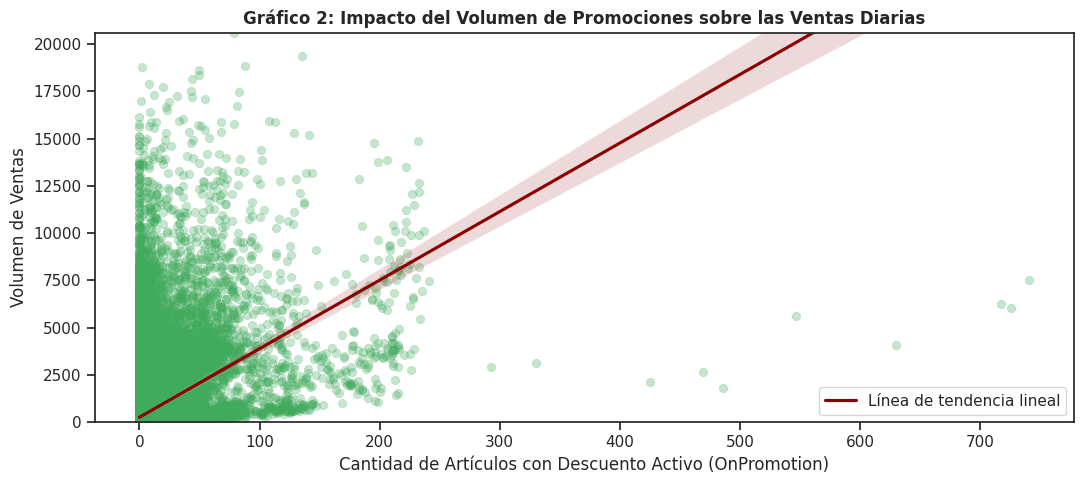

In [16]:
# Gráfico 2: Relación entre Ventas y Artículos en Promoción
plt.figure(figsize=(11, 5))

sns.scatterplot(data=df_visualizacion, x='onpromotion', y='sales', alpha=0.3, color='#41ab5d', edgecolor=None)
sns.regplot(data=df_visualizacion, x='onpromotion', y='sales', scatter=False, color='darkred', label='Línea de tendencia lineal')

plt.title('Gráfico 2: Impacto del Volumen de Promociones sobre las Ventas Diarias', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Artículos con Descuento Activo (OnPromotion)')
plt.ylabel('Volumen de Ventas')
plt.ylim(0, df_visualizacion['sales'].max())
plt.legend()
plt.tight_layout()
plt.show()

**Qué muestra el Gráfico 2:**

El diagrama de dispersión muestra la relación entre la cantidad de productos en promoción (`onpromotion`) y las ventas obtenidas. Se observa una tendencia positiva, es decir, cuando aumenta el número de productos en oferta, las ventas también tienden a incrementarse.

**Qué significa para el proyecto:**

Este resultado indica que las promociones influyen directamente en el comportamiento de compra de los clientes. Por esta razón, la variable `onpromotion` es importante para el modelo predictivo, ya que le ayudará a estimar con mayor precisión los cambios en la demanda y las necesidades de inventario durante campañas promocionales o descuentos especiales.


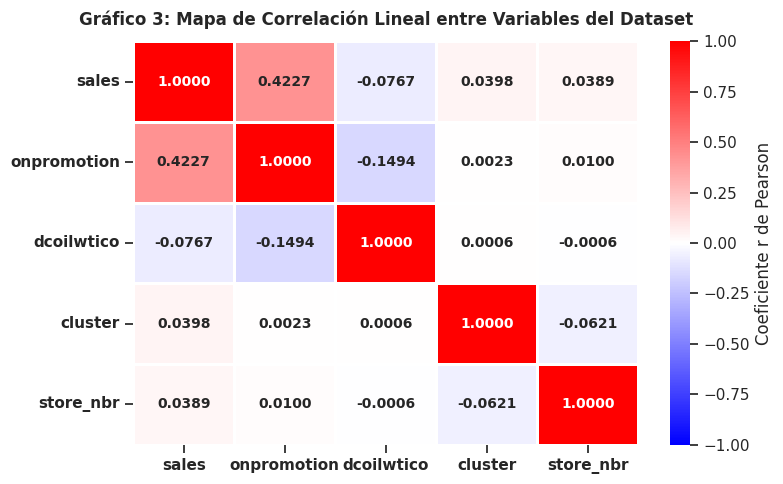

In [17]:
# Gráfico 3: Matriz de Correlación de Pearson
plt.figure(figsize=(8, 5))

columnas_analisis = ['sales', 'onpromotion', 'dcoilwtico', 'cluster', 'store_nbr']
matriz_corr = df_visualizacion[columnas_analisis].corr()

sns.heatmap(matriz_corr, annot=True, cmap='bwr', fmt=".4f", vmin=-1, vmax=1,
            linewidths=1, annot_kws={"size": 10, "weight": "bold"}, cbar_kws={'label': 'Coeficiente r de Pearson'})

plt.title('Gráfico 3: Mapa de Correlación Lineal entre Variables del Dataset', fontsize=12, fontweight='bold', pad=12)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.tight_layout()
plt.show()

**Qué muestra el Gráfico 3:**

El mapa de calor muestra la relación entre las variables numéricas del dataset. Los colores más intensos indican una relación más fuerte entre dos variables, mientras que los colores más suaves representan una relación débil o casi inexistente.

**Qué significa para el proyecto:**

Este gráfico permite identificar qué variables están relacionadas entre sí y verificar que no existan correlaciones excesivamente altas que puedan afectar el rendimiento del modelo. Además, se observa que la relación entre el precio del petróleo (`dcoilwtico`) y las ventas es muy baja, lo que sugiere que los cambios en el petróleo no impactan de forma inmediata en el comportamiento de compra. Por ello, en la siguiente fase se analizarán valores de días anteriores (lags) para determinar si existe un efecto con retraso que pueda mejorar las predicciones.
